# 5. 내재변동성 기반 MC 이론가 재산출 (`mc_iv`) — 자기완결 노트북

`data/raw/iv_daily_atm` 의 **ATM 내재변동성**(역사변동성 대신)과 **bootstrap 할인**(Nelson-Siegel 대신)으로
MC 이론가 `mc_iv` 를 재산출하고, 기존 `mc`(역사변동성·NS) 및 공정가치 `fair` 와 비교한다.

- **자기완결**: `raw/iv_daily_atm` 읽기만 예외로 두고 **모든 함수(FRED 금리 API fetch 포함)를 이 노트북에 인라인**한다. `module.*` 프라이싱 임포트 없음.
- **페이오프 커널**: 기존 `mc` 를 만든 정본 torch 엔진(리자드 우선 · 회차별 쿠폰 · KI, `B≥1`=no-KI)을 **그대로 인라인** → `mc_iv` 와 `mc` 의 차이는 **변동성(IV vs 역사) + 할인(bootstrap vs NS)** 두 가지뿐.
- **변동성**: 지수 8종은 IV(발행일 asof), 단일종목/IV 미제공(2017-01-03 이전 등)은 **역사변동성 폴백**. 상관은 역사(내재상관 데이터 없음).
- **가설**: 내재변동성 > 역사변동성 → worst-of 숏볼 구조라 `mc_iv < mc` → 무보정 MC 의 저가구간 과대평가 편향 축소.

In [1]:
import glob, io, time, urllib.request
from datetime import date
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

# --- 학술/PPT 그림 기본값 (인라인; util.plot 임포트 없이) ---
plt.rcParams.update({"savefig.dpi": 400, "savefig.transparent": True, "savefig.bbox": "tight",
                     "figure.figsize": (13.333, 5.0), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 12, "axes.titleweight": "bold"})

ROOT = Path.cwd()
assert (ROOT / "data").exists(), f"repo 루트에서 실행하세요 (cwd={ROOT})"
DATA, CACHE, RAW = ROOT / "data", ROOT / "data/cache", ROOT / "data/raw"
DEV = "cuda" if torch.cuda.is_available() else "cpu"
NPATH = 100_000                      # 확정: 10만 경로
print("device:", DEV, "| NPATH:", NPATH)

device: cuda | NPATH: 100000


## 1. 데이터 로딩 — 상품(parquet) · 기초자산 수익률(px) · 내재변동성(raw)

In [2]:
# 상품 데이터 (스케줄·udl·기존 mc·fair 완비)
df = pd.read_parquet(DATA / "els3_dataset.parquet").sort_values("isu_ord").reset_index(drop=True)
HIST = "mc_hist" if "mc_hist" in df.columns else "mc"   # 역사-vol MC 기준열(프레임워크 주입 후엔 mc_hist 에 보존; 전엔 mc)
print(f"상품 {len(df):,} | 컬럼 {len(df.columns)} | 역사 MC 열 = '{HIST}'")

# 지수 underlying -> IV RIC (단일종목은 매핑 없음 -> 역사 폴백)
IVMAP = {"^KS200": ".KS200", "^GSPC": ".SPX", "^HSCE": ".HSCE", "^HSI": ".HSI",
         "^N225": ".N225", "^NDX": ".NDX", "^GDAXI": ".GDAXI", "^STOXX50E": ".STOXX50"}

def _safe(t): return "px_" + t.replace("^", "_").replace(".", "_") + ".parquet"

def load_RET(tickers):
    """px_*.parquet -> {ticker: 로그수익률 Series} (역사변동성·상관용)."""
    RET = {}
    for t in tickers:
        f = CACHE / _safe(t)
        if f.exists():
            s = pd.read_parquet(f)["close"].dropna(); s = s[~s.index.duplicated()]
            RET[t] = np.log(s).diff()
    return RET

udls = pd.unique(df[["udl1", "udl2", "udl3"]].values.ravel())
RET = load_RET(udls)
print(f"기초자산 {len(udls)}종 중 수익률 확보 {len(RET)}종")

상품 58,790 | 컬럼 146 | 역사 MC 열 = 'mc_hist'
기초자산 44종 중 수익률 확보 44종


In [3]:
def load_IV():
    """raw/iv_daily_atm 일별 CSV 전량 -> {RIC: date->iv Series}. (유일한 raw 읽기)"""
    files = sorted(glob.glob(str(RAW / "iv_daily_atm/iv_daily_atm/*.csv")))
    big = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    big["calc_date"] = pd.to_datetime(big["calc_date"])
    iv = {}
    for ric, g in big.groupby("notion_ric"):
        s = g.set_index("calc_date")["iv"].sort_index()
        iv[ric] = s[~s.index.duplicated(keep="last")]
    return iv

IV = load_IV()
_lo = min(s.index.min() for s in IV.values()); _hi = max(s.index.max() for s in IV.values())
print(f"IV RIC {len(IV)}종 | 기간 {_lo.date()}~{_hi.date()}")
print("주의: IV 는 {}부터 -> 그 이전 발행 상품은 역사변동성 폴백".format(_lo.date()))

def iv_asof(ticker, dt):
    """발행일 dt 이전 최근 IV. 없으면 nan(-> 역사 폴백)."""
    ric = IVMAP.get(ticker)
    if ric is None or ric not in IV: return np.nan
    s = IV[ric]; s = s[s.index <= dt]
    return float(s.iloc[-1]) if len(s) else np.nan

IV RIC 123종 | 기간 2017-01-03~2026-08-07
주의: IV 는 2017-01-03부터 -> 그 이전 발행 상품은 역사변동성 폴백


## 2. KRW 할인곡선 — FRED 라이브 fetch → bootstrap (NS 대체)

FRED엔 한국 금리가 3 tenor(월별, OECD)뿐: call `IRSTCI01KRM156N` · 3M `IR3TIB01KRM156N` · 10Y `IRLTLT01KRM156N`. 무키 CSV 엔드포인트로 직접 fetch(캐시), 3점 piecewise zero 로 bootstrap.

In [4]:
KR_TAUS = np.array([0.08, 0.25, 10.0])   # call, 3M, 10Y (년)
FRED_KR = {"call": "IRSTCI01KRM156N", "m3": "IR3TIB01KRM156N", "y10": "IRLTLT01KRM156N"}

def fred_csv(series):
    """FRED 무키 CSV 엔드포인트 -> 월별 Series (API key 불필요)."""
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}"
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    raw = urllib.request.urlopen(req, timeout=30).read().decode()
    d = pd.read_csv(io.StringIO(raw)); d.columns = ["date", "v"]
    d["date"] = pd.to_datetime(d["date"]); d["v"] = pd.to_numeric(d["v"], errors="coerce")
    return d.set_index("date")["v"].dropna()

def load_krw_curve():
    """FRED 3계열 라이브 fetch -> [call,m3,y10] 월별 곡선. 캐시(krw_curve_fred.parquet) 재사용."""
    cp = CACHE / "krw_curve_fred.parquet"
    if cp.exists():
        return pd.read_parquet(cp)
    cur = pd.DataFrame({k: fred_csv(s) for k, s in FRED_KR.items()}).sort_index().ffill()
    cur.to_parquet(cp)
    return cur

KRW = load_krw_curve()
print("KRW 곡선(FRED):", KRW.shape, "| 최근:", KRW.dropna().iloc[-1].round(3).to_dict())

def boot_z(row):
    """row=[call,m3,y10] (%) -> z(times) piecewise-linear zero(밖은 flat), 소수 반환."""
    row = np.asarray(row, float)
    if np.isnan(row).any(): return None
    z = row / 100.0
    return lambda times: np.interp(np.atleast_1d(times), KR_TAUS, z)

KRW 곡선(FRED): (426, 3) | 최근: {'call': 2.537, 'm3': 2.91, 'y10': 4.181}


## 3. 변동성·상관 (역사) — 인라인

In [5]:
def vol180(ret, dt):
    """발행 전 180 거래일 연율 변동성(std×√252). 표본<60 -> nan."""
    w = ret[ret.index < dt].tail(180)
    return float(w.std() * np.sqrt(252)) if len(w) >= 60 else np.nan

def corr180(rets, dt):
    """발행 전 180 거래일 정렬 3자산 Pearson 상관. 자료부족 -> None."""
    dfr = pd.concat([r[r.index < dt] for r in rets], axis=1, sort=True).dropna().tail(180)
    if dfr.shape[1] < 3 or len(dfr) < 60: return None
    C = np.corrcoef(dfr.values, rowvar=False); C = np.clip(C, -0.999, 0.999); np.fill_diagonal(C, 1.0)
    return C

def chol_psd(corr):
    """PSD 보정 촐레스키."""
    try:
        return np.linalg.cholesky(corr)
    except np.linalg.LinAlgError:
        ev, V = np.linalg.eigh(corr); ev = np.clip(ev, 1e-8, None)
        c2 = V @ np.diag(ev) @ V.T; d = np.sqrt(np.diag(c2)); c2 = c2 / np.outer(d, d)
        return np.linalg.cholesky(c2)

## 4. 페이오프 커널 (정본 torch 엔진 인라인 — 할인만 bootstrap 주입)

기존 `mc` 를 만든 `mc_engine.mc_daily_t` 를 그대로 옮기되, 할인계수 `DF` 구성만 `disc_z`(bootstrap) 로 바꾼다. 페이오프 로직은 불변.

In [6]:
def _setup(sigs, corr, disc_z, B, strikes, ten, c, pmts, lz_barr, lz_pmt):
    nobs = len(strikes); N = int(round(ten * 365)); dt = 1 / 365
    obs_day = np.clip(np.round(np.arange(1, nobs + 1) * (ten / nobs) * 365).astype(int), 1, N)
    obs_t = obs_day / 365.0
    times = np.arange(1, N + 1) * dt
    DF = np.exp(-disc_z(times) * times)                       # <- NS 대신 bootstrap zero
    fdt = (-(np.diff(np.concatenate([[0.0], np.log(DF)])))).astype(np.float32)
    sig = np.asarray(sigs, np.float32)
    drift = (fdt[:, None] - (0.5 * sig ** 2 * np.float32(dt))[None, :]).astype(np.float32)
    rate = np.asarray(c * obs_t if pmts is None else pmts, np.float32)[:nobs]
    lzb = (np.full(nobs, np.nan, np.float32) if lz_barr is None else np.asarray(lz_barr, np.float32)[:nobs])
    lzp = (np.zeros(nobs, np.float32) if lz_pmt is None else np.nan_to_num(np.asarray(lz_pmt, np.float32))[:nobs])
    on = np.isfinite(lzb)
    return dict(N=N, nobs=nobs, obs_day=obs_day, DF=DF.astype(np.float32),
                L=chol_psd(np.asarray(corr)).astype(np.float32), sig=sig, drift=drift,
                sq=np.float32(np.sqrt(dt)), logB=float(np.log(B)),
                logK=np.log(np.asarray(strikes, np.float32)), rate=rate, lzp=lzp, lz_on=on,
                loglzb=np.log(np.where(on, lzb, 1.0)).astype(np.float32))

def mc_daily_t(sigs, corr, disc_z, B, strikes, ten, n=NPATH, seed=0, c=0.0, pmts=None,
               lz_barr=None, lz_pmt=None, dev=None, path_chunk=20_000, tblock=512):
    """일별 MC (torch). 규칙: 조기상환(회차 지급률) > 리자드(FROM_ISU no-touch) > 만기 KI. B>=1 = no-KI."""
    P = _setup(sigs, corr, disc_z, B, strikes, ten, c, pmts, lz_barr, lz_pmt)
    d = torch.device(dev or DEV); f32 = torch.float32
    N, nobs = P["N"], P["nobs"]
    L = torch.as_tensor(P["L"] * (P["sig"] * P["sq"])[:, None], device=d)
    cdrift = torch.as_tensor(P["drift"], device=d).cumsum(0).T.contiguous()
    DF = torch.as_tensor(P["DF"], device=d); logK = torch.as_tensor(P["logK"], device=d)
    rate = torch.as_tensor(P["rate"], device=d); lzp = torch.as_tensor(P["lzp"], device=d)
    loglzb = torch.as_tensor(P["loglzb"], device=d); lz_on = torch.as_tensor(P["lz_on"], device=d)
    obs_day = torch.as_tensor(P["obs_day"], device=d, dtype=torch.long)
    has_lz = bool(P["lz_on"].any()); always_ki = bool(B >= 1.0); logB = P["logB"]
    g = torch.Generator(device=d).manual_seed(int(seed))
    tot = torch.zeros((), device=d, dtype=torch.float64); done = 0
    while done < n:
        m = min(path_chunk, n - done)
        carry = torch.zeros(3, m, 1, device=d)
        wmin = torch.full((m,), float("inf"), device=d)
        wobs = torch.empty(m, nobs, device=d); wrun = torch.empty(m, nobs, device=d) if has_lz else None
        for t0 in range(0, N, tblock):
            T = min(tblock, N - t0)
            X = torch.randn(3, m, T, device=d, dtype=f32, generator=g)
            X[2] = L[2, 0] * X[0] + L[2, 1] * X[1] + L[2, 2] * X[2]
            X[1] = L[1, 0] * X[0] + L[1, 1] * X[1]; X[0] = L[0, 0] * X[0]
            X = X.cumsum(2); X += carry; carry = X[:, :, -1:].clone()
            X += cdrift[:, None, t0:t0 + T]
            w = torch.minimum(torch.minimum(X[0], X[1]), X[2])
            if has_lz:
                cmin = torch.minimum(torch.cummin(w, dim=1).values, wmin[:, None])
            wmin = torch.minimum(wmin, w.amin(dim=1))
            sel = ((obs_day - 1 >= t0) & (obs_day - 1 < t0 + T)).nonzero(as_tuple=True)[0]
            if sel.numel():
                col = obs_day[sel] - 1 - t0; wobs[:, sel] = w[:, col]
                if has_lz: wrun[:, sel] = cmin[:, col]
        hit = wobs >= logK
        ev = (hit | ((wrun >= loglzb) & lz_on)) if has_lz else hit
        any_ev = ev.any(dim=1); first = ev.to(f32).argmax(dim=1)
        is_reg = hit.gather(1, first[:, None]).squeeze(1)
        pr = torch.where(is_reg, rate[first], lzp[first])
        early = (1.0 + pr) * DF[obs_day[first] - 1]
        wT = torch.minimum(torch.minimum(carry[0, :, 0] + cdrift[0, -1], carry[1, :, 0] + cdrift[1, -1]),
                           carry[2, :, 0] + cdrift[2, -1])
        eT = torch.exp(wT); sv = eT if always_ki else torch.where(wmin < logB, eT, torch.ones_like(eT))
        tot += torch.where(any_ev, early, sv * DF[N - 1]).sum(dtype=torch.float64)
        done += m
    return float(tot.item() / n)

## 5. 상품별 프라이서 — 변동성 벡터(IV/역사) + 상관(역사) + bootstrap 할인

In [7]:
def schedule(r):
    k = int(r["nobs"])
    return ([float(r[f"strk_{j}"]) for j in range(k)], [float(r[f"pmt_{j}"]) for j in range(k)],
            [float(r[f"lz_barr_{j}"]) for j in range(k)], [float(r[f"lz_pmt_{j}"]) for j in range(k)])

def sig_vector(r, dt, ts, use_iv):
    """3자산 변동성. use_iv=True: 지수는 IV(asof), 그 외/미제공은 vol180 폴백. False: 전부 vol180."""
    sigs, n_iv = [], 0
    for t in ts:
        h = vol180(RET[t], dt)
        if use_iv:
            iv = iv_asof(t, dt)
            if not np.isnan(iv): sigs.append(iv); n_iv += 1; continue
        sigs.append(h)
    return sigs, n_iv

def price(r, use_iv, disc, n, seed=None):
    """disc: 'ns' (검증용) | 'boot'. use_iv: True(mc_iv) | False(재현/역사)."""
    dt = pd.Timestamp(date.fromordinal(int(r["isu_ord"]))); ts = [r["udl1"], r["udl2"], r["udl3"]]
    if any(t not in RET for t in ts): return (np.nan, 0)
    corr = corr180([RET[t] for t in ts], dt)
    if corr is None: return (np.nan, 0)
    sigs, n_iv = sig_vector(r, dt, ts, use_iv)
    if any(np.isnan(sigs)): return (np.nan, 0)
    krow = KRW.asof(dt).values
    if disc == "boot":
        dz = boot_z(krow)
    else:                                   # NS (검증 baseline)
        b, *_ = np.linalg.lstsq(np.stack([np.ones(3), (1-np.exp(-KR_TAUS/1.5))/(KR_TAUS/1.5),
                 (1-np.exp(-KR_TAUS/1.5))/(KR_TAUS/1.5)-np.exp(-KR_TAUS/1.5)], 1), krow, rcond=None) \
                 if not np.isnan(krow).any() else (None,)
        if b is None: return (np.nan, 0)
        def dz(times, b=b):
            t = np.maximum(np.atleast_1d(times), 1e-6); x = t/1.5; e = np.exp(-x)
            return (np.stack([np.ones_like(t), (1-e)/x, (1-e)/x-e], 1) @ b) / 100.0
    if dz is None: return (np.nan, 0)
    strikes, pmts, lzb, lzp = schedule(r)
    s = int(r["mc_seed"]) if seed is None else seed
    m = mc_daily_t(sigs, corr, dz, float(r["B"]), strikes, float(r["tenor"]), n=n, seed=s,
                   c=float(r["coupon"]), pmts=pmts, lz_barr=lzb, lz_pmt=lzp)
    return (m, n_iv)

## 6. 검증 — 인라인 엔진이 커밋된 `mc` 를 재현하는가 (역사 vol + NS + 40k + seed=mc_seed)

In [8]:
_idx = df["udl1"].isin(IVMAP) & df["udl2"].isin(IVMAP) & df["udl3"].isin(IVMAP)
val = df[_idx].iloc[::3000].head(15)
rep = [(r["item"], r[HIST], price(r, use_iv=False, disc="ns", n=40000)[0]) for _, r in val.iterrows()]
rep = pd.DataFrame(rep, columns=["item", "mc_hist_committed", "mc_repro"]); rep["diff"] = rep.mc_repro - rep.mc_hist_committed
print(rep.round(5).to_string(index=False))
print(f"\nmax|diff|={rep['diff'].abs().max():.5f} mean|diff|={rep['diff'].abs().mean():.5f}  (< ~0.001 이면 엔진 충실)")
assert rep["diff"].abs().max() < 0.005, "재현 오차 큼 — 엔진/입력 점검"

        item  mc_hist_committed  mc_repro     diff
KR6523318519            0.99982   0.99896 -0.00085
KR6523307595            0.94532   0.94511 -0.00021
KR6573335678            0.99440   0.99458  0.00018
KR6503351738            1.00668   1.00679  0.00012
KR65033CJ7A4            1.02200   1.02195 -0.00005
KR65233AX848            1.00256   1.00303  0.00047
KR65333AP8A3            1.00269   1.00288  0.00019
KR65333EA937            0.99504   0.99511  0.00008
KR6553374986            0.98943   0.98955  0.00012
KR6653324A16            1.00550   1.00544 -0.00006
KR6523303A81            0.89233   0.89329  0.00096
KR6BK0000379            0.94318   0.94284 -0.00035
KR6MZ00011Z1            0.96108   0.96103 -0.00006
KR6MD0002NK5            0.98867   0.98903  0.00037
KR6ZW00012B8            0.93804   0.93842  0.00038

max|diff|=0.00096 mean|diff|=0.00030  (< ~0.001 이면 엔진 충실)


## 7. `mc_iv` 전량 산출 (IV vol + bootstrap, 100k)

전량(58,790)은 GPU에서 ~1시간. `SUBSAMPLE` 로 소량 반복 가능. 결측(px/스케줄) 은 NaN.

In [9]:
SUBSAMPLE = 300     # None = 전량(약 1시간). 정수 = 발행일 전구간 균등 샘플(빠른 확인; IV 실사용 포함).
work = df.copy() if SUBSAMPLE is None else df.iloc[np.linspace(0, len(df) - 1, SUBSAMPLE).astype(int)].copy()
mc_iv = np.full(len(work), np.nan); n_iv_udl = np.zeros(len(work), dtype=int)
t0 = time.time()
for pos, (_, r) in enumerate(work.iterrows()):
    m, niv = price(r, use_iv=True, disc="boot", n=NPATH)
    mc_iv[pos] = m; n_iv_udl[pos] = niv
    if (pos + 1) % 200 == 0:
        el = time.time() - t0; print(f"{pos+1}/{len(work)} ({el:.0f}s, ETA {el/(pos+1)*(len(work)-pos-1)/60:.1f}분)", flush=True)
work = work.assign(mc_iv=mc_iv, n_iv_udl=n_iv_udl)
ok = work["mc_iv"].notna()
print(f"\n완료 {int(ok.sum())}/{len(work)} | {time.time()-t0:.0f}s | IV로 3자산 다 채운 상품 {int((work.n_iv_udl==3).sum())} "
      f"| 부분 {int(((work.n_iv_udl>0)&(work.n_iv_udl<3)).sum())} | 전부 역사폴백 {int((work.n_iv_udl==0).sum())}")

200/300 (14s, ETA 0.1분)



완료 300/300 | 22s | IV로 3자산 다 채운 상품 233 | 부분 26 | 전부 역사폴백 41


## 8. 비교 · 저장 — `mc_iv` vs `mc`(역사) vs `fair`

In [10]:
FACE = 10000
c = work[work["mc_iv"].notna()].copy()
c["fair_minus_mc"] = c["fair"] - c[HIST]; c["fair_minus_mc_iv"] = c["fair"] - c["mc_iv"]
c["mc_iv_minus_mc"] = c["mc_iv"] - c[HIST]
iv3 = c[c["n_iv_udl"] == 3]      # IV 를 실제로 3자산 다 쓴 상품(순수 비교)
print(f"[전체 {len(c)}] mean fair-mc={c.fair_minus_mc.mean()*FACE:+.0f}원 -> fair-mc_iv={c.fair_minus_mc_iv.mean()*FACE:+.0f}원 "
      f"| mc_iv-mc={c.mc_iv_minus_mc.mean()*FACE:+.0f}원")
print(f"[IV 3자산 {len(iv3)}] mean fair-mc={iv3.fair_minus_mc.mean()*FACE:+.0f}원 -> fair-mc_iv={iv3.fair_minus_mc_iv.mean()*FACE:+.0f}원 "
      f"| mc_iv-mc={iv3.mc_iv_minus_mc.mean()*FACE:+.0f}원")

# 저장 (mc 덮어쓰지 않음)
outp = ROOT / "result/statistics/mc_iv.csv"; outp.parent.mkdir(parents=True, exist_ok=True)
c.assign(mc_hist=c[HIST])[["item", "isu_ord", "opt_type", "ki_yn", "fair", "mc_hist", "mc_iv", "n_iv_udl"]].to_csv(outp, index=False, encoding="utf-8-sig")
print("saved ->", outp.relative_to(ROOT))

[전체 300] mean fair-mc=-570원 -> fair-mc_iv=-493원 | mc_iv-mc=-77원
[IV 3자산 233] mean fair-mc=-606원 -> fair-mc_iv=-492원 | mc_iv-mc=-114원
saved -> result\statistics\mc_iv.csv


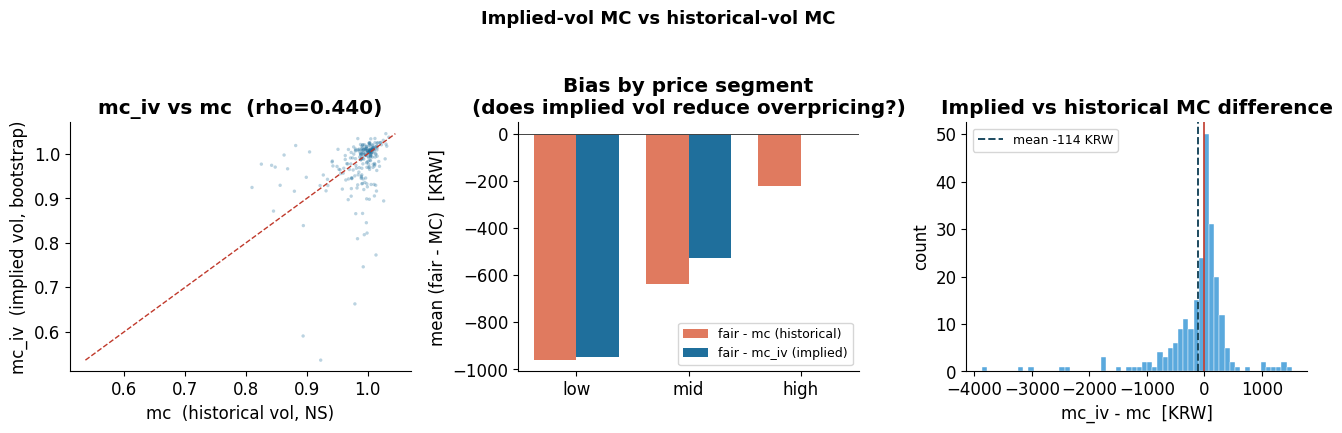

saved -> result/image/mc_iv_vs_mc.png


In [11]:
# 그림: (1) mc_iv vs mc 산점  (2) 편향 축소: (fair-mc) vs (fair-mc_iv) 구간별  (3) mc_iv-mc 히스토
from scipy.stats import spearmanr
fig, ax = plt.subplots(1, 3, figsize=(13.333, 4.4))
s = iv3 if len(iv3) > 30 else c
lim = [min(s[HIST].min(), s.mc_iv.min()), max(s[HIST].max(), s.mc_iv.max())]
ax[0].scatter(s[HIST], s.mc_iv, s=6, alpha=.3, color="#1f6f9c", edgecolors="none")
ax[0].plot(lim, lim, "--", color="#c0392b", lw=1)
ax[0].set_xlabel("mc  (historical vol, NS)"); ax[0].set_ylabel("mc_iv  (implied vol, bootstrap)")
ax[0].set_title(f"mc_iv vs mc  (rho={spearmanr(s[HIST], s.mc_iv).correlation:.3f})")

q = np.quantile(s.fair, [1/3, 2/3]); seg = np.where(s.fair <= q[0], "low", np.where(s.fair <= q[1], "mid", "high"))
segs = ["low", "mid", "high"]; x = np.arange(3); w = 0.38
b1 = [(s.fair_minus_mc[seg == g]).mean() * FACE for g in segs]
b2 = [(s.fair_minus_mc_iv[seg == g]).mean() * FACE for g in segs]
ax[1].bar(x - w/2, b1, w, label="fair - mc (historical)", color="#e07a5f")
ax[1].bar(x + w/2, b2, w, label="fair - mc_iv (implied)", color="#1f6f9c")
ax[1].axhline(0, color="#444", lw=.7); ax[1].set_xticks(x); ax[1].set_xticklabels(["low", "mid", "high"])
ax[1].set_ylabel("mean (fair - MC)  [KRW]")
ax[1].set_title("Bias by price segment\n(does implied vol reduce overpricing?)"); ax[1].legend(fontsize=9)

ax[2].hist(s.mc_iv_minus_mc * FACE, bins=60, color="#5aa9dd", edgecolor="white", lw=.3)
ax[2].axvline(0, color="#c0392b", lw=1.2)
ax[2].axvline(s.mc_iv_minus_mc.mean() * FACE, color="#1c4a5f", lw=1.4, ls="--",
             label=f"mean {s.mc_iv_minus_mc.mean()*FACE:+.0f} KRW")
ax[2].set_xlabel("mc_iv - mc  [KRW]"); ax[2].set_ylabel("count")
ax[2].set_title("Implied vs historical MC difference"); ax[2].legend(fontsize=9)
fig.suptitle("Implied-vol MC vs historical-vol MC", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(ROOT / "result/image/mc_iv_vs_mc.png"); plt.show()
print("saved -> result/image/mc_iv_vs_mc.png")

## 9. NS vs bootstrap 할인 비교

같은 mc_iv 를 NS 할인과 bootstrap 할인으로 각각 산출해 (1) zero 곡선 모양, (2) 가격 차이를 본다. (KR 금리는 FRED 3점뿐이라 bootstrap 은 3점 piecewise.)

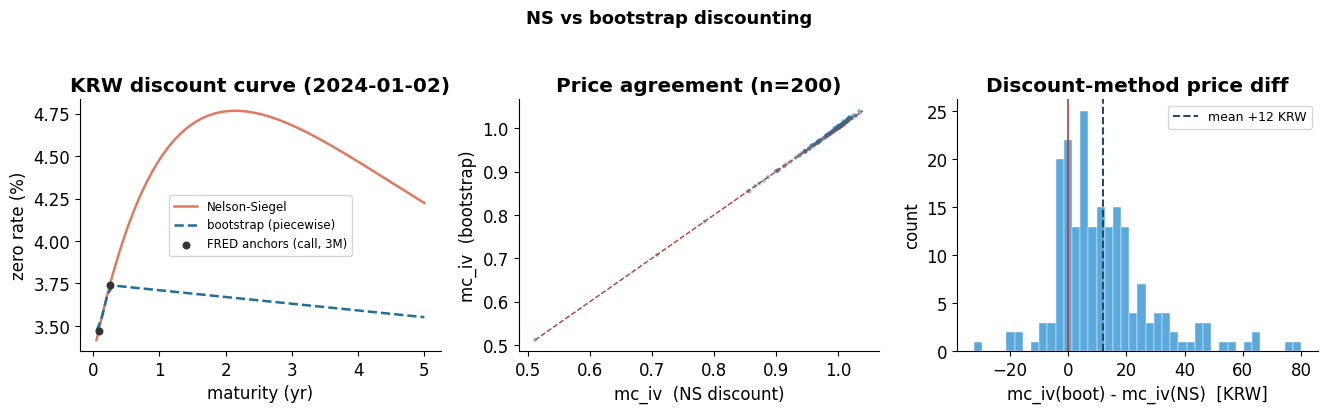

NS vs bootstrap | mc_iv 차이 mean +12.1 KRW, std 16.8, max|.| 80


In [12]:
# NS zero (검증용 helper) + bootstrap zero 곡선 + 표본 가격차
def _nsb(t):
    t = np.atleast_1d(np.asarray(t, float)); x = t / 1.5; e = np.exp(-x)
    return np.stack([np.ones_like(t), (1 - e) / x, (1 - e) / x - e], 1)
ref = pd.Timestamp("2024-01-02"); krow = KRW.asof(ref).values
beta, *_ = np.linalg.lstsq(_nsb(KR_TAUS), krow, rcond=None)
tt = np.linspace(0.05, 5.0, 60)
z_ns = (_nsb(tt) @ beta) / 100.0
z_bs = np.interp(tt, KR_TAUS, krow / 100.0)

# 표본 200개: mc_iv(NS) vs mc_iv(bootstrap), 40k 경로
smp = df.iloc[np.linspace(0, len(df) - 1, 200).astype(int)]
p_ns, p_bs = [], []
for _, r in smp.iterrows():
    p_ns.append(price(r, use_iv=True, disc="ns", n=40000)[0])
    p_bs.append(price(r, use_iv=True, disc="boot", n=40000)[0])
p_ns, p_bs = np.array(p_ns), np.array(p_bs); ok = ~(np.isnan(p_ns) | np.isnan(p_bs))
p_ns, p_bs = p_ns[ok], p_bs[ok]; dd = (p_bs - p_ns) * FACE

fig, ax = plt.subplots(1, 3, figsize=(13.333, 4.2))
ax[0].plot(tt, z_ns * 100, color="#e07a5f", lw=1.8, label="Nelson-Siegel")
ax[0].plot(tt, z_bs * 100, color="#1f6f9c", lw=1.8, ls="--", label="bootstrap (piecewise)")
ax[0].scatter(KR_TAUS[:2], krow[:2], c="#333", s=22, zorder=5, label="FRED anchors (call, 3M)")
ax[0].set_xlabel("maturity (yr)"); ax[0].set_ylabel("zero rate (%)")
ax[0].set_title(f"KRW discount curve ({ref.date()})"); ax[0].legend(fontsize=8.5)
lim = [min(p_ns.min(), p_bs.min()), max(p_ns.max(), p_bs.max())]
ax[1].scatter(p_ns, p_bs, s=9, alpha=.4, color="#1f6f9c", edgecolors="none"); ax[1].plot(lim, lim, "--", color="#c0392b", lw=1)
ax[1].set_xlabel("mc_iv  (NS discount)"); ax[1].set_ylabel("mc_iv  (bootstrap)"); ax[1].set_title(f"Price agreement (n={len(p_ns)})")
ax[2].hist(dd, bins=40, color="#5aa9dd", edgecolor="white", lw=.3); ax[2].axvline(0, color="#c0392b", lw=1.2)
ax[2].axvline(dd.mean(), color="#1c4a5f", lw=1.4, ls="--", label=f"mean {dd.mean():+.0f} KRW")
ax[2].set_xlabel("mc_iv(boot) - mc_iv(NS)  [KRW]"); ax[2].set_ylabel("count"); ax[2].set_title("Discount-method price diff"); ax[2].legend(fontsize=9)
fig.suptitle("NS vs bootstrap discounting", fontsize=13, fontweight="bold"); fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(ROOT / "result/image/mc_iv_ns_vs_bootstrap.png"); plt.show()
print(f"NS vs bootstrap | mc_iv 차이 mean {dd.mean():+.1f} KRW, std {dd.std():.1f}, max|.| {np.abs(dd).max():.0f}")

## 10. MC 진단 그림 (1_MC_recompute 방식) — mc_iv vs 역사 mc, 전량

`1_MC_recompute` 의 두 그림(공정가−MC 히스토그램, 가격구간별 오차/MAPE)을 mc_iv 로 재작성하고 역사 mc 와 겹쳐 본다. 전량(mc_iv_full.csv).

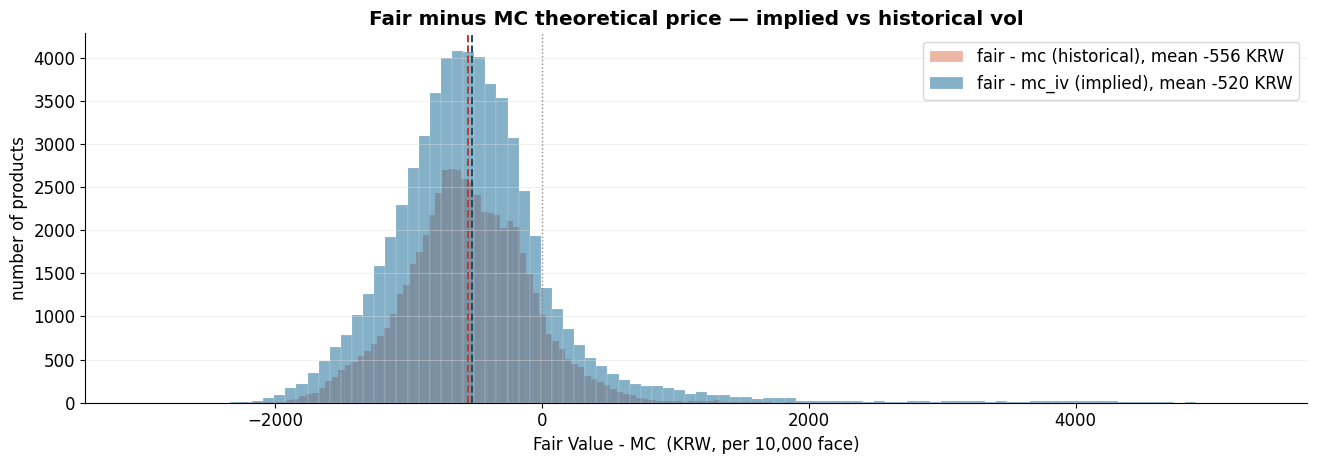

fair-mc(hist) mean -556 | fair-mc_iv mean -520 | 편향 축소 -36 KRW


In [13]:
full = pd.read_csv(ROOT / "result/statistics/mc_iv_full.csv", encoding="utf-8-sig")
FACE = 10000
d_h = (full.fair - full.mc) * FACE          # fair - 역사 mc
d_iv = (full.fair - full.mc_iv) * FACE      # fair - mc_iv

# 그림 1: (fair - MC) 히스토그램 — 역사 vs 내재 겹침
fig, ax = plt.subplots(figsize=(13.333, 4.8))
ax.hist(d_h, bins=100, color="#e07a5f", alpha=.55, edgecolor="white", lw=.2, label=f"fair - mc (historical), mean {d_h.mean():,.0f} KRW")
ax.hist(d_iv, bins=100, color="#1f6f9c", alpha=.55, edgecolor="white", lw=.2, label=f"fair - mc_iv (implied), mean {d_iv.mean():,.0f} KRW")
ax.axvline(d_h.mean(), color="#c0392b", lw=1.4, ls="--"); ax.axvline(d_iv.mean(), color="#1c4a5f", lw=1.4, ls="--")
ax.axvline(0, color="#888", lw=1, ls=":")
ax.set_xlabel("Fair Value - MC  (KRW, per 10,000 face)"); ax.set_ylabel("number of products")
ax.set_title("Fair minus MC theoretical price — implied vs historical vol")
ax.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6); ax.legend()
fig.tight_layout(); fig.savefig(ROOT / "result/image/mc_iv_fair_minus_mc_hist.png"); plt.show()
print(f"fair-mc(hist) mean {d_h.mean():,.0f} | fair-mc_iv mean {d_iv.mean():,.0f} | 편향 축소 {d_h.mean()-d_iv.mean():+,.0f} KRW")

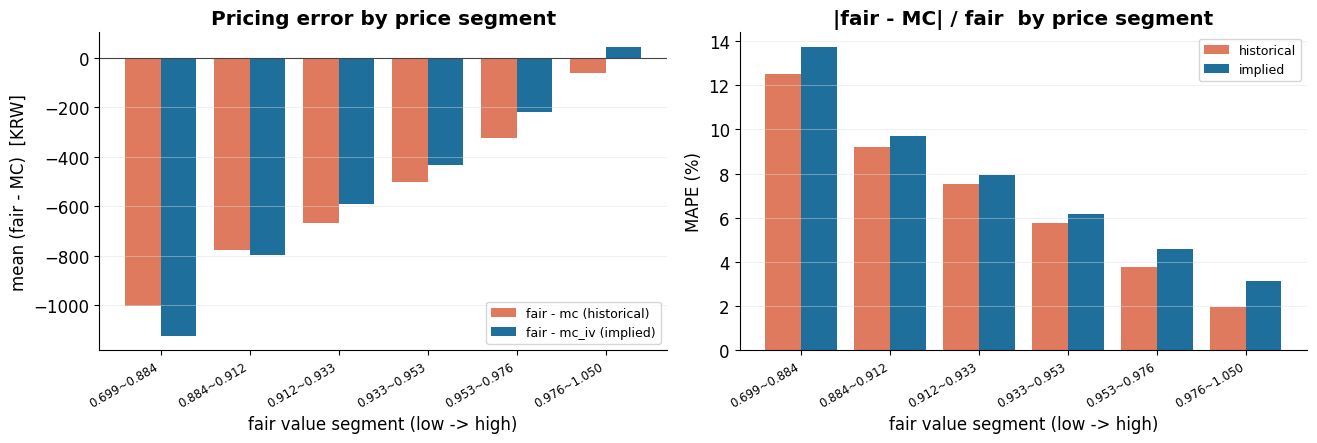

                 err_h  err_iv  ape_h  ape_iv
seg                                          
(0.699, 0.884] -1004.1 -1122.5   12.5    13.7
(0.884, 0.912]  -778.5  -795.5    9.2     9.7
(0.912, 0.933]  -668.2  -592.8    7.5     7.9
(0.933, 0.953]  -501.0  -432.1    5.8     6.2
(0.953, 0.976]  -322.7  -221.1    3.7     4.6
(0.976, 1.05]    -61.5    43.8    2.0     3.1


In [14]:
# 그림 2: 공정가 6분위 구간별 (fair - MC) 오차 + MAPE — 역사 vs 내재
seg = pd.qcut(full.fair, 6)
t = full.assign(seg=seg,
                err_h=(full.fair - full.mc) * FACE, err_iv=(full.fair - full.mc_iv) * FACE,
                ape_h=(full.fair - full.mc).abs() / full.fair.abs() * 100,
                ape_iv=(full.fair - full.mc_iv).abs() / full.fair.abs() * 100)
g = t.groupby("seg", observed=True).agg(err_h=("err_h", "mean"), err_iv=("err_iv", "mean"),
                                        ape_h=("ape_h", "mean"), ape_iv=("ape_iv", "mean"))
xs = np.arange(len(g)); xl = [f"{i.left:.3f}~{i.right:.3f}" for i in g.index]; w = 0.4
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.6))
ax[0].bar(xs - w/2, g.err_h, w, color="#e07a5f", label="fair - mc (historical)")
ax[0].bar(xs + w/2, g.err_iv, w, color="#1f6f9c", label="fair - mc_iv (implied)")
ax[0].axhline(0, color="#444", lw=.8); ax[0].set_xticks(xs); ax[0].set_xticklabels(xl, rotation=30, fontsize=8.5, ha="right")
ax[0].set_ylabel("mean (fair - MC)  [KRW]"); ax[0].set_xlabel("fair value segment (low -> high)")
ax[0].set_title("Pricing error by price segment"); ax[0].legend(fontsize=9); ax[0].grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
ax[1].bar(xs - w/2, g.ape_h, w, color="#e07a5f", label="historical"); ax[1].bar(xs + w/2, g.ape_iv, w, color="#1f6f9c", label="implied")
ax[1].set_xticks(xs); ax[1].set_xticklabels(xl, rotation=30, fontsize=8.5, ha="right")
ax[1].set_ylabel("MAPE (%)"); ax[1].set_xlabel("fair value segment (low -> high)")
ax[1].set_title("|fair - MC| / fair  by price segment"); ax[1].legend(fontsize=9); ax[1].grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
fig.tight_layout(); fig.savefig(ROOT / "result/image/mc_iv_err_by_price_seg.png"); plt.show()
print(g.round(1).to_string())